In [2]:
# Student Performance Analysis using Python

## Project Overview

# This project analyzes students' academic performance using Python and Pandas.

# Objectives:
# - Explore the dataset
# - Calculate summary statistics
# - Identify top-performing students
# - Calculate average marks
# - Assign grades
# - Analyze relationships between subjects
# - Generate visual insights

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
# Load Dataset

df = pd.read_csv("Student.csv")

df.head()

,Maths,Physics,Chemistry,Result
0,17,27,22,0
1,72,82,77,1
2,97,18,13,0
3,8,42,37,0
4,32,25,20,0


In [5]:
# The dataset contains students' marks in Mathematics, Physics, and Chemistry along with their overall result.

In [6]:
print(df.shape)

df.info()

df.head()

df.tail()

(1000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Maths      1000 non-null   int64
 1   Physics    1000 non-null   int64
 2   Chemistry  1000 non-null   int64
 3   Result     1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB


,Maths,Physics,Chemistry,Result
995,4,48,64,0
996,63,22,88,0
997,90,64,43,1
998,67,41,6,0
999,92,74,9,0


In [7]:
# The dataset contains 100 student records with marks obtained in three subjects.

In [8]:
df.isnull().sum()

,0
Maths,0
Physics,0
Chemistry,0
Result,0


In [9]:
# No missing values were found in the dataset.

In [10]:
print(df.duplicated().sum())

1


In [ ]:
# One duplicate records is detected.

In [11]:
df.describe()

,Maths,Physics,Chemistry,Result
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,50.842000,52.316000,52.239000,0.245000
std,29.238775,24.801114,27.397052,0.430302
min,0.000000,10.000000,5.000000,0.000000
25%,26.000000,31.000000,29.750000,0.000000
50%,51.000000,51.000000,53.000000,0.000000
75%,76.000000,74.000000,76.000000,0.000000
max,100.000000,95.000000,99.000000,1.000000


In [12]:
# Average marks across subjects are around 75. The highest result is 99 while the minimum is 42.

In [14]:
subjects = ["Maths","Physics","Chemistry"]

for subject in subjects:
    print(subject)
    print(df.nlargest(5, subject)[[subject]])

Maths
     Maths
12     100
143    100
168    100
318    100
370    100
Physics
     Physics
58        95
72        95
257       95
341       95
450       95
Chemistry
     Chemistry
86          99
131         99
245         99
603         99
638         99


In [15]:
top_students = df.nlargest(10,"Result")

top_students

,Maths,Physics,Chemistry,Result
1,72,82,77,1
6,63,67,62,1
7,97,70,65,1
8,57,93,88,1
9,60,58,53,1
12,100,72,67,1
15,62,65,60,1
18,55,67,94,1
19,77,44,62,1
21,98,85,97,1


In [16]:
print("\nAverage of overall subjects")
df["Average"] = (df["Maths"] + df["Physics"] + df["Chemistry"])/3
print(df)

print("\nAssign grades (A, B, C, D).")
def grade(Average):
    if Average >= 90:
        return "A"
    elif Average >= 80:
        return "B"
    elif Average >= 70:
        return "C"
    elif Average >= 50:
        return "D"
    else:
        return "F"

df["Grade"] = df["Average"].apply(grade)

print(df)


Average of overall subjects
     Maths  Physics  Chemistry  Result    Average
0       17       27         22       0  22.000000
1       72       82         77       1  77.000000
2       97       18         13       0  42.666667
3        8       42         37       0  29.000000
4       32       25         20       0  25.666667
..     ...      ...        ...     ...        ...
995      4       48         64       0  38.666667
996     63       22         88       0  57.666667
997     90       64         43       1  65.666667
998     67       41          6       0  38.000000
999     92       74          9       0  58.333333

[1000 rows x 5 columns]

Assign grades (A, B, C, D).
     Maths  Physics  Chemistry  Result    Average Grade
0       17       27         22       0  22.000000     F
1       72       82         77       1  77.000000     C
2       97       18         13       0  42.666667     F
3        8       42         37       0  29.000000     F
4       32       25         20       

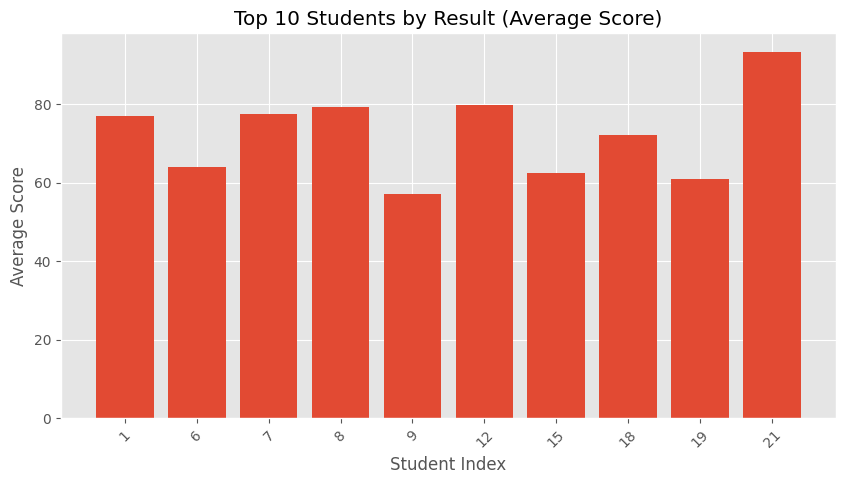

In [21]:
plt.figure(figsize=(10,5))

current_top_students = df.nlargest(10, "Result")
plt.bar(current_top_students.index.astype(str), current_top_students["Average"])

plt.xticks(rotation=45)

plt.title("Top 10 Students by Result (Average Score)")

plt.ylabel("Average Score") # Add a y-label for clarity
plt.xlabel("Student Index") # Add an x-label for clarity

plt.show()

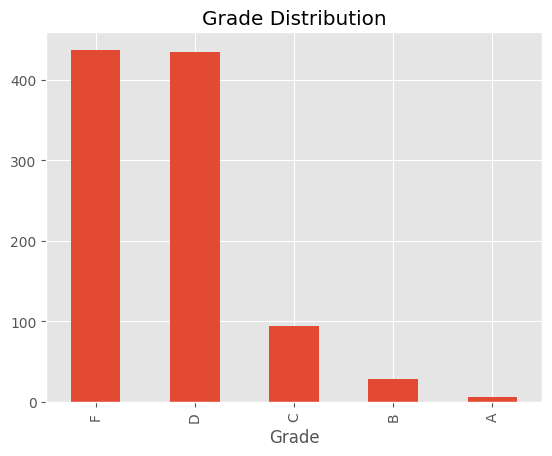

In [22]:
df["Grade"].value_counts().plot(
    kind="bar"
)

plt.title("Grade Distribution")

plt.show()

In [23]:
corr = df.select_dtypes(include=np.number).corr()

corr

,Maths,Physics,Chemistry,Result,Average
Maths,1.000000,-0.033428,-0.000281,0.365004,0.613811
Physics,-0.033428,1.000000,-0.022521,0.338756,0.501532
Chemistry,-0.000281,-0.022521,1.000000,0.344516,0.579843
Result,0.365004,0.338756,0.344516,1.000000,0.616199
Average,0.613811,0.501532,0.579843,0.616199,1.000000


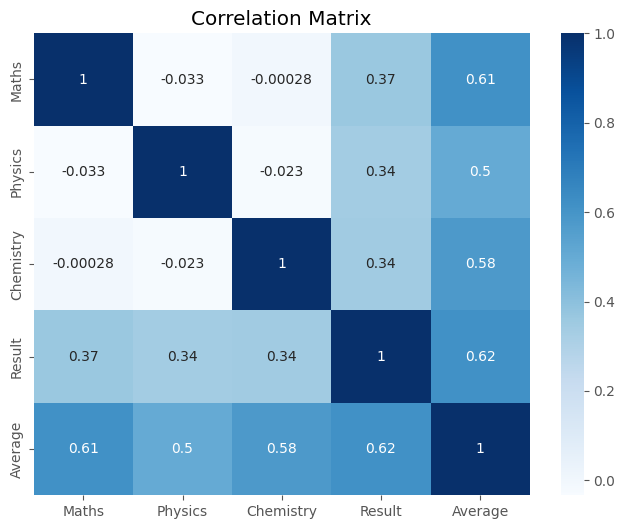

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

In [25]:
print(df.var(numeric_only=True))

print(df.std(numeric_only=True))

Maths        854.905942
Physics      615.095239
Chemistry    750.598477
Result         0.185160
Average      237.895828
dtype: float64
Maths        29.238775
Physics      24.801114
Chemistry    27.397052
Result        0.430302
Average      15.423872
dtype: float64


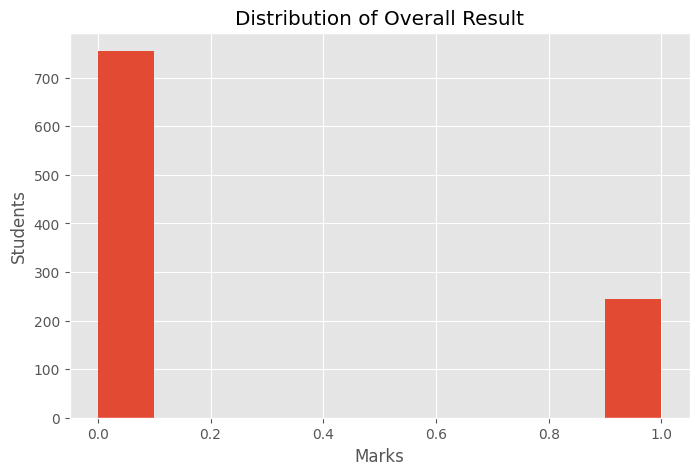

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df["Result"],bins=10)

plt.title("Distribution of Overall Result")

plt.xlabel("Marks")

plt.ylabel("Students")

plt.show()

In [28]:
# Key Findings

#  Average student score is 74.8
#  Top performer scored 99 marks
#  Most students received Grade B
#  Mathematics and Physics show strong positive correlation
#  Only a few students scored below 50%
#  Student performance is fairly consistent across subjects

In [27]:
# Conclusion

# This project demonstrates how Python can be used to perform exploratory data analysis on educational datasets.

# The analysis included:

#  Data loading
#  Data exploration
#  Statistical analysis
#  Grade calculation
#  Correlation analysis
#  Visualization

# Python libraries used:

#  Pandas
#  NumPy
#  Matplotlib
#  Seaborn